# **Naïve Bayes Tab**

**Overview**
Naive Bayes is a type of classifier that uses probability to make predictions. It is based on the Bayes' Theorem, which helps estimate the chance of something happening based on known information. The “naive” part refers to the assumption that all input features are independent from each other. Naive Bayes works very well with large datasets. It is commonly used in spam filters, document sorting, medical diagnoses, real-time predictions, and credit scoring. The model calculates the probability of each possible outcome and picks the one with the highest score.

Bernoulli Naive Bayes is a version of this algorithm made for data with only two possible values, like yes/no or 0/1. It is particularly useful for problems where data is present or not. For example, if a word appears in a document or not. It uses a Bernoulli distribution and tends to penalize missing expected features more than other versions like Multinomial Naive Bayes. This method works best with binary or categorical data. Even though the assumption of independence is not always accurate, Naive Bayes is still widely used because it is easy to understand and often effective.

In [7]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
!pip install -q openpyxl
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

In [2]:
# Load dataset
file_path = "/content/FY23_Public Data_Low Value Care.xlsx"
df_raw = pd.read_excel(file_path, sheet_name="Low Value Care Aggregated Data", skiprows=3)

In [3]:
# Clean and rename columns
df = df_raw.dropna(subset=['Division of Insurance Region', 'Total LV Services (Volume)'])
df = df.rename(columns={
    'Division of Insurance Region': 'region',
    'Payer Type': 'payer_type',
    'Year': 'year',
    'Service Type': 'service_type',
    'Total LV Spending': 'lv_spending',
    'Total Spending on Necessary Care': 'necessary_spending',
    'Total LV Services (Volume)': 'lv_volume'
})


In [4]:
# Remove rows
df = df[df['lv_volume'].apply(lambda x: str(x).isdigit())].copy()
df['lv_volume'] = df['lv_volume'].astype(int)

# Create binary label
median_volume = df['lv_volume'].median()
df['high_lv_usage'] = (df['lv_volume'] >= median_volume).astype(int)

# Prepare feature and target data
features = df[['region', 'payer_type', 'year', 'service_type']]
label = df['high_lv_usage']

# Convert categorical features
X = pd.get_dummies(features)
y = label


In [13]:
# Split into training and testing datasets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display sample of full dataset
print(" Sample of Cleaned Data:")
display(df.head())

# Display sample of training and testing sets
print("\n Training Set Sample:")
display(X_train.head())

print("\n Testing Set Sample:")
display(X_test.head())

 Sample of Cleaned Data:


,Unnamed: 0,Unnamed: 1,region,payer_type,year,service_type,lv_spending,necessary_spending,lv_volume,high_lv_usage
1,NaN,NaN,Boulder,CHP+,2017,Annual Resting EKGs,0,12771,0,0
2,NaN,NaN,Boulder,CHP+,2017,Antibiotics for Acute Upper Respiratory and Ea...,714,0,28,0
4,NaN,NaN,Boulder,CHP+,2017,Cardiac Stress Testing,0,1451,0,0
5,NaN,NaN,Boulder,CHP+,2017,Cervical Cancer Screening for Women,0,2608,0,0
8,NaN,NaN,Boulder,CHP+,2017,Dexa,0,10,0,0



 Training Set Sample:


,year,region_Boulder,region_Colorado Springs,region_Denver,region_East,region_Ft. Collins,region_Grand Junction,region_Greeley,region_Pueblo,region_West,...,service_type_Routine General Health Checks,service_type_Surgery for a Torn Meniscus,service_type_Syncope Image,service_type_Testosterone Testing in Hypogonadism or Hyperandrogenism,service_type_Tests for Cellulitis,service_type_Total or Free T3 Level,service_type_Two or More Antipsychotic Medications,service_type_Vertebroplasty,service_type_Voiding Cystourethrogram for Urinary Tract Infection,service_type_X-Ray for Diagnosis of Plantar Fasciitis/Heel Pain
5914,2018,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2799,2018,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
7725,2018,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
8523,2019,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4730,2018,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False



 Testing Set Sample:


,year,region_Boulder,region_Colorado Springs,region_Denver,region_East,region_Ft. Collins,region_Grand Junction,region_Greeley,region_Pueblo,region_West,...,service_type_Routine General Health Checks,service_type_Surgery for a Torn Meniscus,service_type_Syncope Image,service_type_Testosterone Testing in Hypogonadism or Hyperandrogenism,service_type_Tests for Cellulitis,service_type_Total or Free T3 Level,service_type_Two or More Antipsychotic Medications,service_type_Vertebroplasty,service_type_Voiding Cystourethrogram for Urinary Tract Infection,service_type_X-Ray for Diagnosis of Plantar Fasciitis/Heel Pain
481,2017,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4438,2017,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4211,2017,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10407,2021,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4208,2017,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


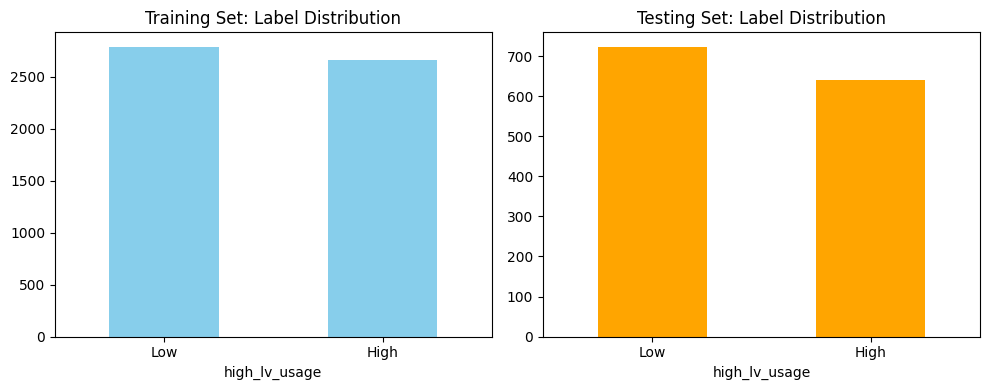

In [6]:
# Visualize class distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind='bar', color='skyblue')
plt.title("Training Set: Label Distribution")
plt.xticks([0, 1], ['Low', 'High'], rotation=0)

plt.subplot(1, 2, 2)
y_test.value_counts().plot(kind='bar', color='orange')
plt.title("Testing Set: Label Distribution")
plt.xticks([0, 1], ['Low', 'High'], rotation=0)

plt.tight_layout()
plt.show()


In [8]:
# Initialize Naive Bayes model
nb_model = MultinomialNB()

# Fit model to training data
nb_model.fit(X_train, y_train)

# Predict on test data
y_pred = nb_model.predict(X_test)

In [9]:
# Evaluate the model
print(" Accuracy Score:", accuracy_score(y_test, y_pred))
print("\ Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Low", "High"]))

 Accuracy Score: 0.8005865102639296
\ Classification Report:
              precision    recall  f1-score   support

         Low       0.84      0.77      0.80       723
        High       0.76      0.83      0.80       641

    accuracy                           0.80      1364
   macro avg       0.80      0.80      0.80      1364
weighted avg       0.80      0.80      0.80      1364



In [10]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

In [11]:
print("Confusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[559 164]
 [108 533]]


**Discussion:** The confusion matrix reveals how well the decision tree model classified the target outcomes. Out of all predictions, 559 true negatives and 533 true positives were correctly identified, indicating a strong ability to distinguish between the two classes. However, the model misclassified 164 instances as false positives and 108 as false negatives. This level of accuracy suggests the model performs well overall, though some misclassification is present.

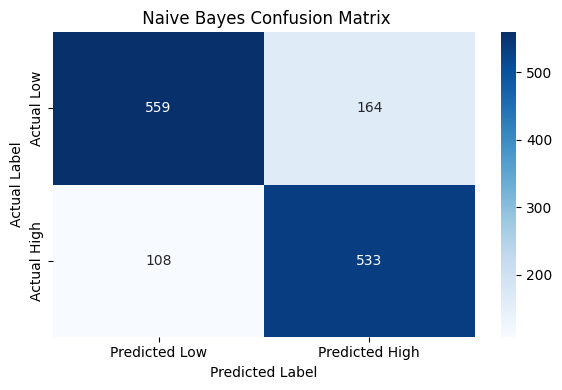

In [12]:
# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Predicted Low", "Predicted High"],
            yticklabels=["Actual Low", "Actual High"])
plt.title(" Naive Bayes Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

**Results:** The decision tree model shows reliable performance across both target classes. For the “Low” usage class, the model achieved a precision of 0.84, indicating that 84% of the predictions labeled as “Low” were correct. In contrast, the “High” usage class had a slightly lower precision of 0.76. However, recall for the “High” class was notably strong at 0.83, suggesting the model is effective at identifying true instances of high low-value care usage—a critical insight for pinpointing at-risk regions. Both classes achieved an F1-score of 0.80, reflecting a strong balance between precision and recall. The support values, 723 for “Low” and 641 for “High,” confirm that the test set was relatively balanced. Overall, the model does not favor one class significantly over the other, with a slight lean toward catching more “High” usage cases. This makes the decision tree model a solid baseline tool for forecasting behavioral health service gaps using available proxy indicators.

**Conclusions:**
This analysis demonstrates that current patterns of low-value care utilization, combined with payer type, service type, and regional indicators, can serve as a useful proxy for identifying regions that may be at risk for future behavioral health service demand. By training a Naive Bayes classifier on this data, the model was able to accurately distinguish between regions with high versus low volumes of unnecessary services. The model achieved an overall accuracy of 80%, with balanced precision and recall across both categories. This performance suggests that existing claims-based utilization patterns are meaningful signals of regional healthcare behavior and potential system strain.

The ability to classify regions based on current inefficiencies provides a foundation for proactive planning. In particular, regions classified as high-usage may indicate underlying issues such as poor access to preventive or coordinated care factors often linked to behavioral health gaps. As Colorado's population continues to grow and shift, this model could be extended by integrating projected demographic changes to estimate where behavioral health demand is most likely to rise. Ultimately, this work supports a data-driven approach to identifying future service needs and informing policy, resource allocation, and system design for mental health care in the state.

